# Notebook 08 — Julia Backend

pyUDE provides an optional Julia backend (`JuliaNODE`, `JuliaCustomDerivatives`,
`JuliaCustomDifferences`) that delegates ODE integration and network training to
[UniversalDiffEq.jl](https://jack-h-buckner.github.io/UniversalDiffEq.jl/dev/).

**Choose Julia when you need:**
- Stiff ODE solvers (`Rodas5`, `QNDF`) from DifferentialEquations.jl
- High-order, high-accuracy solvers (`Vern9`)
- Tight integration with the Julia scientific ecosystem

**Choose PyTorch when you need:**
- GPU acceleration, custom architectures, dropout, `param_bounds`, `save()`/`load_weights()`

> All Julia cells are wrapped in `if JULIA_AVAILABLE:` guards so this notebook runs
> without error on machines where Julia is not installed.

## Installation

```bash
# 1. Install Julia >= 1.10 from https://julialang.org/downloads
# 2. Install pyUDE with the Julia extra:
pip install 'pyUDE[julia]'
# 3. First run: Julia auto-downloads and compiles UniversalDiffEq.jl (~2–5 min)
```

> **First-run JIT warm-up:** The first call to `model.train()` starts Julia and
> compiles the package. Expect ~60 s on first use; subsequent calls are fast (~1 s).

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pyUDE as ude

np.random.seed(11)

try:
    import juliacall  # must be importable for Julia to work
    from pyUDE import JuliaNODE, JuliaCustomDerivatives, JuliaCustomDifferences
    JULIA_AVAILABLE = True
    print('Julia backend available.')
except ImportError:
    JULIA_AVAILABLE = False
    JuliaNODE = JuliaCustomDerivatives = JuliaCustomDifferences = None
    print('Julia backend not available — install with: pip install "pyUDE[julia]"')

## 1 — Generate Data: Lotka-Volterra

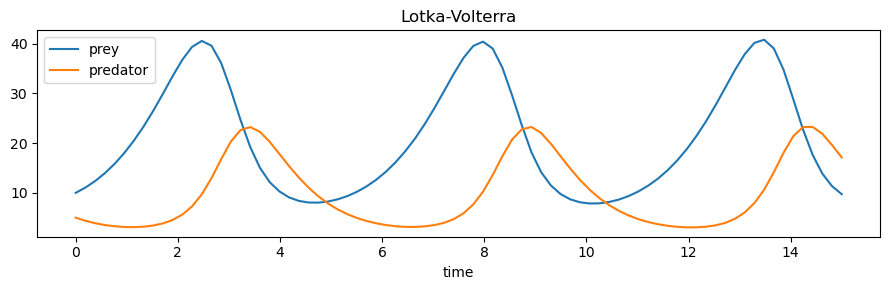

In [2]:
def lv_rhs(t, u):
    x, y = u
    return [x - 0.1*x*y, -1.5*y + 0.075*x*y]

sol = solve_ivp(lv_rhs, [0, 15], [10.0, 5.0],
                t_eval=np.linspace(0, 15, 80), method='RK45')
lv_data = pd.DataFrame({'time': sol.t, 'prey': sol.y[0], 'predator': sol.y[1]})

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(sol.t, sol.y[0], label='prey')
ax.plot(sol.t, sol.y[1], label='predator')
ax.legend(); ax.set_xlabel('time'); ax.set_title('Lotka-Volterra')
plt.tight_layout(); plt.show()

## 2 — `JuliaNODE` — Basic Usage

The constructor signature matches `NODE` but there is no `device=` or `network=`
parameter. The solver is set at construction time (not training time).

In [3]:
if JULIA_AVAILABLE:
    model_jnode = JuliaNODE(
        lv_data,
        hidden_units=32,
        hidden_layers=2,
        solver='Tsit5',   # explicit 5th-order, good for non-stiff
    )
    print(model_jnode)
    print('Julia starts lazily — training cell will trigger JIT compilation...')
else:
    print('Skipping JuliaNODE — Julia not installed.')

Skipping JuliaNODE — Julia not installed.


In [4]:
if JULIA_AVAILABLE:
    model_jnode.train(epochs=300, learning_rate=1e-3, verbose=True)
    print('is_trained:', model_jnode.is_trained)
    fc_jnode = model_jnode.forecast(steps=30)
    print('Forecast shape:', fc_jnode.shape, fc_jnode.head(3))

## 3 — Solver Reference

| Solver | Type | Use case |
|--------|------|----------|
| `"Tsit5"` | Explicit 5th-order | Default, non-stiff |
| `"Vern9"` | Explicit 9th-order | High accuracy, smooth |
| `"Rodas5"` | Implicit 5th-order | **Stiff** (fast–slow dynamics) |
| `"QNDF"` | Implicit variable-order | Stiff, like MATLAB `ode15s` |
| `"AutoTsit5(Rosenbrock23())"` | Auto-switching | Unknown stiffness |

Pass the solver string at **construction time**, not training time.

## 4 — Stiff System: Van der Pol with `Rodas5`

`Tsit5` (explicit) can fail or diverge on stiff systems because the step-size
constraint becomes very restrictive. An implicit solver like `Rodas5` handles
stiff problems efficiently.

In [5]:
def vdp(t, u, mu=2.0):
    x, y = u
    return [y, mu*(1 - x**2)*y - x]

vdp_sol = solve_ivp(vdp, [0, 20], [2.0, 0.0],
                    t_eval=np.linspace(0, 20, 120), method='Radau')
vdp_data = pd.DataFrame({'time': vdp_sol.t, 'x': vdp_sol.y[0], 'y': vdp_sol.y[1]})

if JULIA_AVAILABLE:
    # Stiff solver
    model_stiff = JuliaNODE(vdp_data, hidden_units=32, solver='Rodas5')
    model_stiff.train(epochs=300, learning_rate=1e-3, verbose=False)
    fc_stiff = model_stiff.forecast(steps=20)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(vdp_data['time'], vdp_data['x'], 'k.', ms=3, alpha=0.5, label='data')
    ax.plot(fc_stiff['time'], fc_stiff['x'], 'r-', lw=2, label='forecast (Rodas5)')
    ax.axvline(vdp_data['time'].iloc[-1], color='k', ls='--')
    ax.legend(); ax.set_title('Van der Pol — JuliaNODE with Rodas5')
    plt.tight_layout(); plt.show()
else:
    print('Skipping — Julia not installed.')

Skipping — Julia not installed.


## 5 — `JuliaCustomDerivatives` — Signature Difference

The `known_dynamics` function for the Julia backend receives **plain Python lists
and floats**, not PyTorch tensors. This is because the function is called from
Julia via PythonCall.jl during ODE integration.

```python
# PyTorch backend — tensors
def known_pt(u, p, t):
    return torch.stack([p['alpha'] * u[0], -p['delta'] * u[1]])

# Julia backend — plain lists/floats
def known_jl(u, p, t):
    return [p['alpha'] * u[0], -p['delta'] * u[1]]
```

In [6]:
# Julia backend known_dynamics: u is list, p values are floats, t is float
def lv_known_julia(u, p, t):
    prey, pred = u[0], u[1]
    return [p['alpha'] * prey, -p['delta'] * pred]

if JULIA_AVAILABLE:
    model_jcd = JuliaCustomDerivatives(
        lv_data, lv_known_julia,
        init_params={'alpha': 0.8, 'delta': 1.2},
        hidden_units=32,
        solver='Tsit5',
    )
    model_jcd.train(epochs=400, learning_rate=1e-3, verbose=False)
    print('Recovered params:', model_jcd.get_params())
else:
    print('Skipping — Julia not installed.')

Skipping — Julia not installed.


## 6 — `JuliaCustomDifferences`

In [7]:
t_map = np.arange(60, dtype=float)
x_map = np.zeros(60); x_map[0] = 3.6
for i in range(1, 60):
    x_map[i] = 3.6 * x_map[i-1] * (1 - x_map[i-1] / 10) + 0.05*np.random.randn()
map_data = pd.DataFrame({'time': t_map, 'x': x_map})

def logistic_known_jl(u, p, t):
    """Julia backend: u and p are plain Python types."""
    return [p['r'] * u[0] * (1 - u[0] / 10.0)]

if JULIA_AVAILABLE:
    model_jdiff = JuliaCustomDifferences(
        map_data, logistic_known_jl, init_params={'r': 3.0}
    )
    model_jdiff.train(epochs=300, learning_rate=1e-3, verbose=False)
    print('Recovered r:', model_jdiff.get_params())
else:
    print('Skipping — Julia not installed.')

Skipping — Julia not installed.


## 7 — `get_right_hand_side()` with scipy

The Julia-trained model's RHS is callable from Python tools via PythonCall.jl.

In [8]:
if JULIA_AVAILABLE and model_jnode.is_trained:
    from scipy.integrate import odeint

    rhs = model_jnode.get_right_hand_side()
    u0 = lv_data[['prey', 'predator']].iloc[0].values
    t_span = np.linspace(0, 20, 200)

    sol_scipy = odeint(rhs, y0=u0, t=t_span)

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(lv_data['time'], lv_data['prey'], 'b.', ms=3, label='data (prey)')
    ax.plot(t_span, sol_scipy[:, 0], 'b-', lw=2, label='scipy odeint (prey)')
    ax.legend(); ax.set_title('Julia RHS integrated with scipy.odeint')
    plt.tight_layout(); plt.show()
else:
    print('Skipping — Julia not installed or model not trained.')

Skipping — Julia not installed or model not trained.


## 8 — PyTorch vs Julia Comparison

In [9]:
import torch

# PyTorch backend
model_pt = ude.NODE(lv_data, hidden_units=32, hidden_layers=2)
model_pt.train(loss='derivative_matching', epochs=150, verbose=False)
fc_pt = model_pt.forecast(steps=30)

_, test_lv = ude.train_test_split(lv_data, test_fraction=0.25)
min_l = min(len(fc_pt), len(test_lv))
state_cols = ['prey', 'predator']
rmse_pt = ude.rmse(test_lv[state_cols].iloc[:min_l].reset_index(drop=True),
                   fc_pt[state_cols].iloc[:min_l].reset_index(drop=True))['mean']
print(f'PyTorch NODE test RMSE: {rmse_pt:.4f}')

if JULIA_AVAILABLE and model_jnode.is_trained:
    fc_jl = model_jnode.forecast(steps=30)
    rmse_jl = ude.rmse(test_lv[state_cols].iloc[:min_l].reset_index(drop=True),
                       fc_jl[state_cols].iloc[:min_l].reset_index(drop=True))['mean']
    print(f'JuliaNODE test RMSE:   {rmse_jl:.4f}')
else:
    print('Julia comparison skipped — Julia not installed.')

PyTorch NODE test RMSE: 23.7044
Julia comparison skipped — Julia not installed.


## 9 — Limitations

| Feature | PyTorch backend | Julia backend |
|---------|----------------|---------------|
| GPU support (`device=`) | ✓ | — |
| Custom `nn.Module` (`network=`) | ✓ | — |
| `dropout` | ✓ | — |
| `param_bounds` | ✓ | — |
| `save()` / `load_weights()` | ✓ | — |
| Derivative-matching loss | ✓ | — |
| `val_data` / `train_history_` | ✓ | — |
| Stiff solvers (`Rodas5`, `QNDF`) | limited | ✓ |
| High-order solvers (`Vern9`) | — | ✓ |
| DifferentialEquations.jl ecosystem | — | ✓ |

## 10 — PythonCall Bridge Performance Note

`JuliaCustomDerivatives` calls your Python `known_dynamics` function from Julia at
**every ODE right-hand-side evaluation** — potentially millions of times per training
run. Each call crosses the Python↔Julia boundary, adding ~1–5 µs overhead.

**Recommendations:**
- Keep `known_dynamics` simple (a few multiplications / additions)
- Avoid Python loops or NumPy calls inside `known_dynamics`
- If `known_dynamics` is complex, consider moving it to a Julia file using the
  lower-level UniversalDiffEq.jl API directly

## Key Takeaways

- The Julia backend is **optional** (`pip install 'pyUDE[julia]'`) and starts lazily.
- Use `JuliaNODE` / `JuliaCustomDerivatives` / `JuliaCustomDifferences` when stiff
  solvers or high-order integration accuracy is needed.
- `known_dynamics` for Julia uses **plain lists and floats** — no PyTorch operations.
- `get_right_hand_side()` and `get_params()` work identically to the PyTorch backend.
- For GPU, dropout, param_bounds, or save/load, use the PyTorch backend.
- `if JULIA_AVAILABLE:` guards make notebooks portable to machines without Julia.